#

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json 

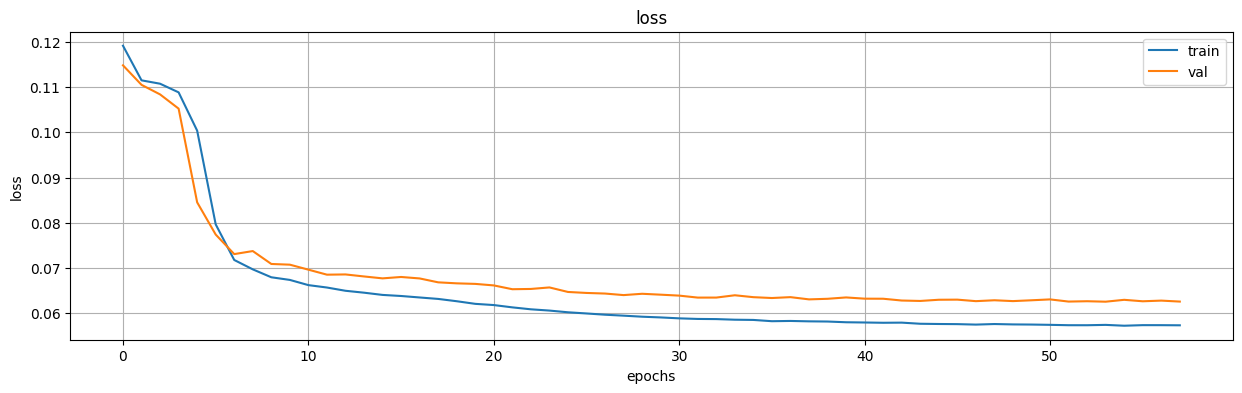

In [3]:
output_size = 64
i = 8
fn = "../Results/ADSB_Paper/ADSB_{}/Res_{}/"


with open(fn.format(output_size,i)+"Training/training_history.json", "r") as f:
    h = json.load(f)

keys = ['loss']

for k in keys:
    plt.figure(figsize=(15, 4))
    plt.plot(h[k],label='train')
    plt.plot(h['val_'+k],label='val')
    plt.title(k)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.grid(True)
    plt.legend()
    plt.show()

In [4]:
# data = np.load(fn.format(output_size,i)+'Results/final.npy',allow_pickle=True).item()
data = np.load(fn.format(output_size,i)+'Training/threshold.npy',allow_pickle=True).item()
# data = np.load(fn.format(output_size,i)+'Training/threshold_val.npy',allow_pickle=True).item()

print(data.keys())

dict_keys(['Loss', 'Corr', 'flag'])


99 0.012346996255219003
100 0.044257525
0.1


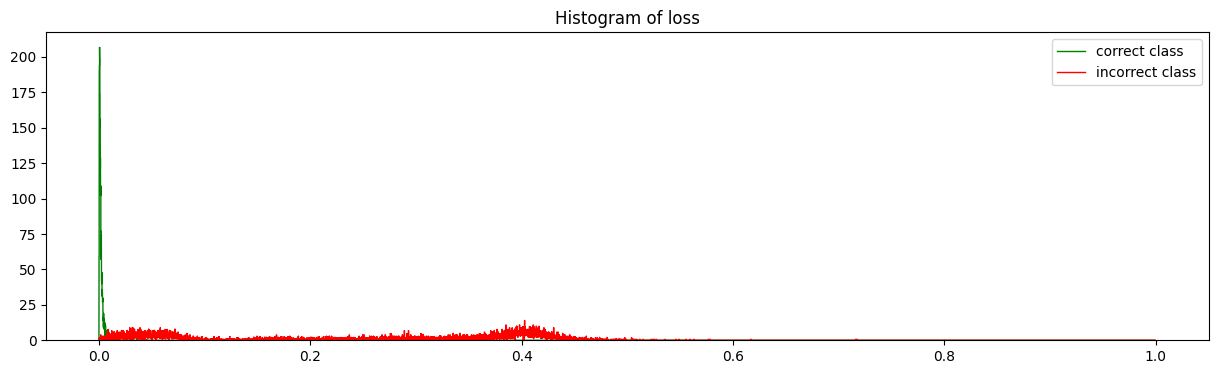

In [6]:

pos = data['flag']==1
neg = ~pos
print(99,np.percentile(data['Loss'][pos],99))
print(100,np.max(data['Loss'][pos]))
pos_max = np.ceil(np.max(data['Loss'][pos])*10)/10
print(pos_max)
plt.figure(figsize=(15, 4))
counts, bins = np.histogram(data['Loss'][pos],bins=np.arange(0,1,0.0001))
plt.stairs(counts, bins,color='green',label='correct class')
counts, bins = np.histogram(data['Loss'][neg],bins=np.arange(0,1,0.0001))
plt.stairs(counts, bins,color='red',label='incorrect class')
plt.title("Histogram of loss")
plt.legend()
# plt.xlim(-0.01,pos_max)
plt.show()


In [58]:
def cal_recall(loss,pos,th):
    org_pos = pos
    true_pos = (loss<th)&pos
    return np.sum(true_pos)/np.sum(org_pos)

def cal_precision(loss, pos,th):
    true_pos = (loss<th)&pos
    all_pos = (loss<th)
    return np.sum(true_pos)/np.sum(all_pos)

def F1_score(loss, pos,th):
    recall = cal_recall(loss,pos,th)
    precision = cal_precision(loss,pos,th)
    return 2*(recall*precision)/(recall+precision)


0.9899699097291875
0.6824546240276578
0.079058655 0.8486037387491346 0.5929506246281975 0.9997492477432297


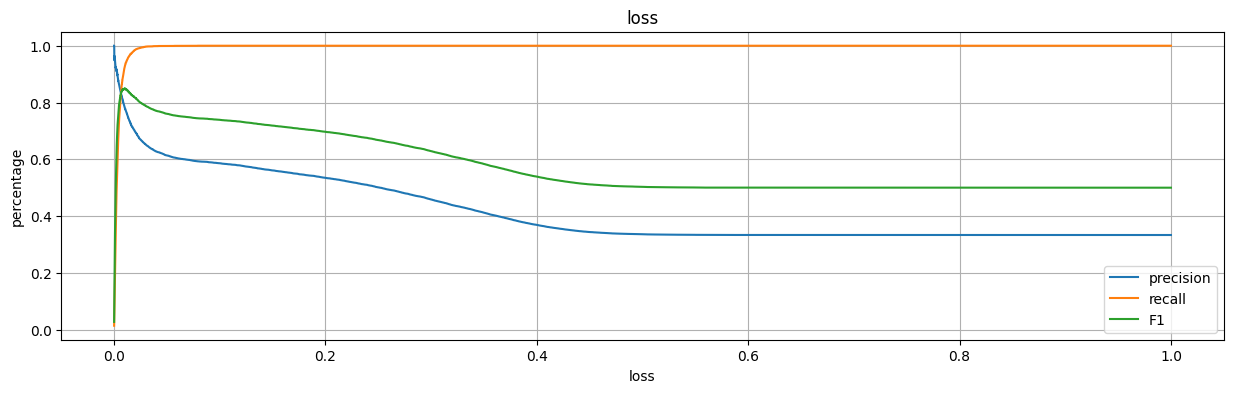

In [59]:
th = np.percentile(data['Loss'][pos],99)
print(cal_recall(data['Loss'],pos,th))
print(cal_precision(data['Loss'],pos,th))

th_range = np.arange(0.0001,1,0.00001)

f1 = [F1_score(data['Loss'],pos,th) for th in th_range]
th = th_range[np.argmax(f1)]
th = np.max(data['Loss'][pos])

print(th,np.max(f1),cal_precision(data['Loss'],pos,th),cal_recall(data['Loss'],pos,th))

plt.figure(figsize=(15, 4))
plt.plot(th_range,[cal_precision(data['Loss'],pos,th) for th in th_range],label='precision')
plt.plot(th_range,[cal_recall(data['Loss'],pos,th) for th in th_range],label='recall')
plt.plot(th_range,[F1_score(data['Loss'],pos,th) for th in th_range],label='F1')
plt.title('loss')
plt.xlabel('loss')
plt.ylabel('percentage')
plt.legend()
plt.grid(True)
# plt.xlim(-0.0001,0.05)
plt.show()


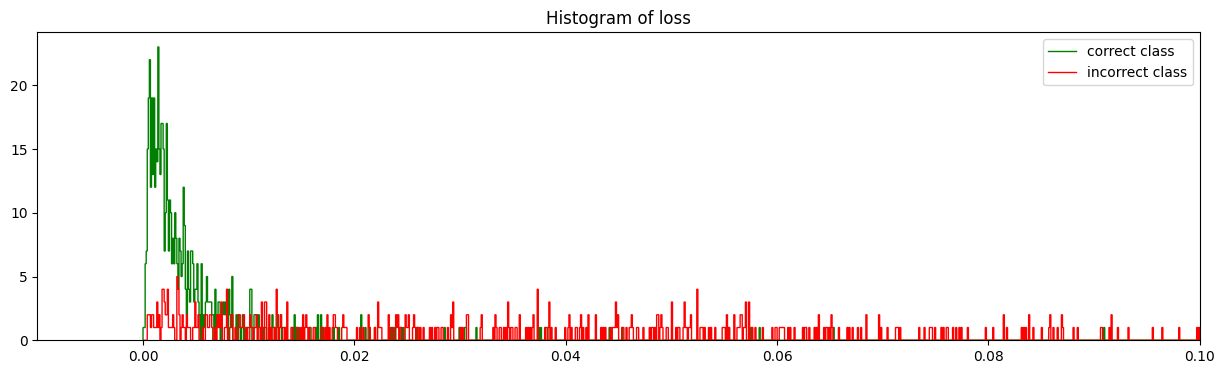

In [53]:
data = np.load(fn.format(output_size,i)+'Training/threshold_val.npy',allow_pickle=True).item()
pos = data['flag']==1
neg = ~pos
plt.figure(figsize=(15, 4))
counts, bins = np.histogram(data['Loss'][pos],bins=np.arange(0,1,0.0001))
plt.stairs(counts, bins,color='green',label='correct class')
counts, bins = np.histogram(data['Loss'][neg],bins=np.arange(0,1,0.0001))
plt.stairs(counts, bins,color='red',label='incorrect class')
plt.title("Histogram of loss")
plt.legend()
plt.xlim(-0.01,pos_max)
plt.show()

0.048053637 0.7980652962515115 0.6673407482305359 0.9924812030075187


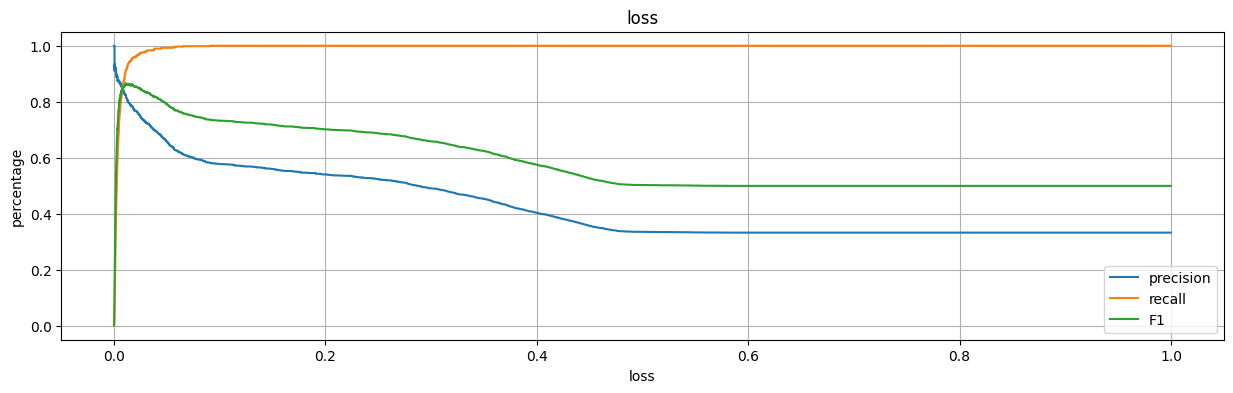

In [54]:
print(th,F1_score(data['Loss'],pos,th),cal_precision(data['Loss'],pos,th),cal_recall(data['Loss'],pos,th))

plt.figure(figsize=(15, 4))
plt.plot(th_range,[cal_precision(data['Loss'],pos,th) for th in th_range],label='precision')
plt.plot(th_range,[cal_recall(data['Loss'],pos,th) for th in th_range],label='recall')
plt.plot(th_range,[F1_score(data['Loss'],pos,th) for th in th_range],label='F1')
plt.title('loss')
plt.xlabel('loss')
plt.ylabel('percentage')
plt.legend()
plt.grid(True)
# plt.xlim(-0.0001,0.05)
plt.show()


# Accuracy 
We first show the accuracy per feature, 

In [14]:
class Result:
    def __init__(self,outputsize=2, avg=True,ttype='recall',key='recall') -> None:
        self.count=32
        self.output_size = outputsize
        self.fn=f'../Results/ADSB_Paper/ADSB_{outputsize}'+'/Res_{}/Results/info.json'
        self.accuracy,self.maximum = self.get_avg(ttype,key) if avg else self.get_max(ttype,key)
    
    def get_avg(self,ttype,key):
        res = 0
        c = 0
        for i in range(self.count):
            with open(self.fn.format(i), "r") as outfile:
                info =  json.load(outfile)
                res+=info[ttype][key]
                c+=1
        return res/c, -1
    
    def get_max(self,ttype,key):
        res = 0
        ires = -1
        for i in range(self.count):
            with open(self.fn.format(i), "r") as outfile:
                info =  json.load(outfile)

                tmp = info[ttype][key]
                if tmp>res:
                    res = tmp
                    ires = i
                
        return res,ires
r = Result(4,ttype='F1',key='precision',avg=False)
print(r.accuracy)

0.7774390243902439


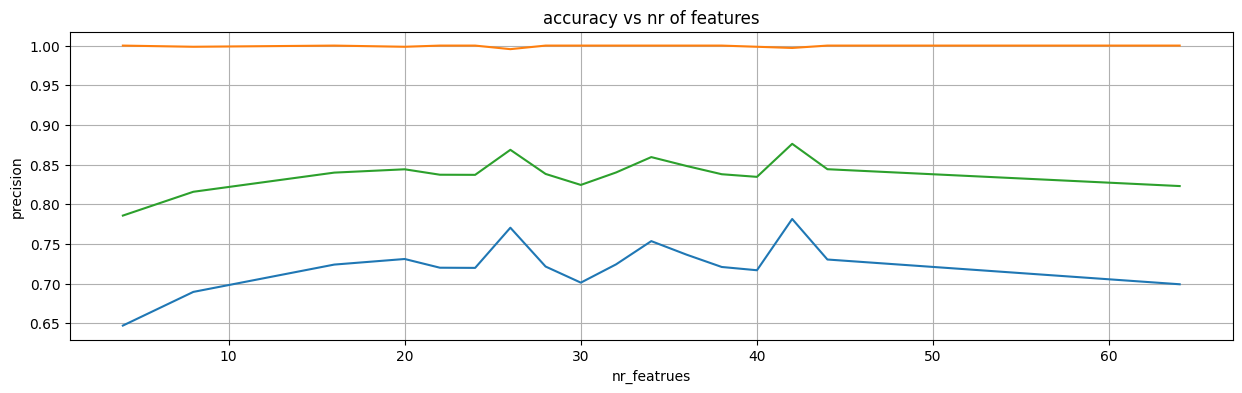

In [26]:
ttype='recall'
key = 'precision'
avg = False

sizes = [4,8,16,20,22,24,26,28,30,32,34,36,38,40,42,44,64]

plt.figure(figsize=(15, 4))
resp = [Result(s,avg=avg,ttype=ttype,key=key) for s in sizes]
res = [r.accuracy for r in resp]
plt.plot(sizes,res)

resc = [Result(s,avg=avg,ttype=ttype,key='recall') for s in sizes]
res = [r.accuracy for r in resc]
plt.plot(sizes,res)


res = [2*(r.accuracy*p.accuracy)/(r.accuracy+p.accuracy) for r,p in zip(resc,resp)]
plt.plot(sizes,res)
plt.title('accuracy vs nr of features')
plt.xlabel('nr_featrues')
plt.ylabel(key)
plt.grid(True)
plt.show()

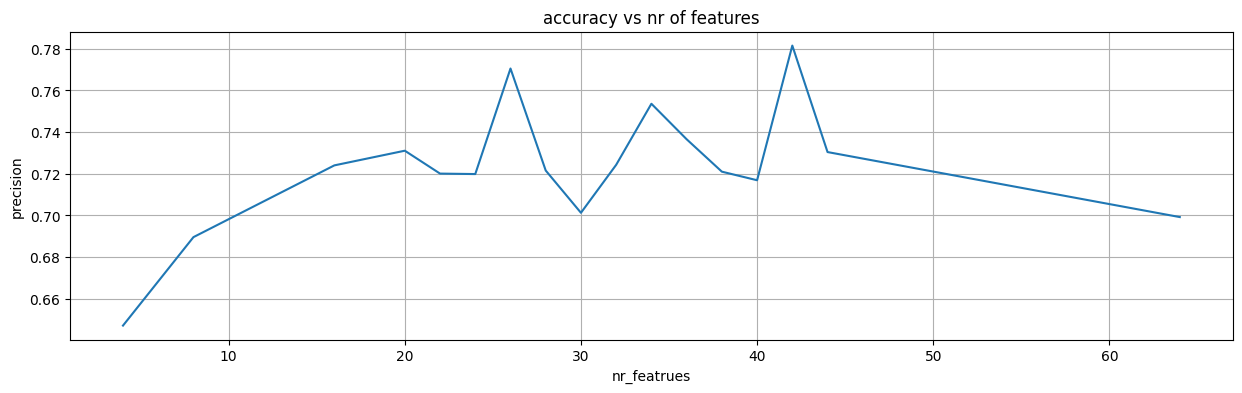

[(4, 18, 0.6470588235294118), (8, 13, 0.6895074946466809), (16, 18, 0.7239467849223947), (20, 28, 0.7309875141884222), (22, 10, 0.72), (24, 10, 0.7197802197802198), (26, 6, 0.7704326923076923), (28, 21, 0.7214765100671141), (30, 13, 0.7011866235167206), (32, 12, 0.7242152466367713), (34, 23, 0.7535211267605634), (36, 26, 0.7364864864864865), (38, 2, 0.7209302325581395), (40, 20, 0.7168141592920354), (42, 27, 0.7814407814407814), (44, 23, 0.7303370786516854), (64, 3, 0.6991341991341992)]


In [28]:
ttype='recall'
key = 'precision'
avg = False

sizes = [4,8,16,20,22,24,26,28,30,32,34,36,38,40,42,44,64]

plt.figure(figsize=(15, 4))
resc = [Result(s,avg=avg,ttype=ttype,key=key) for s in sizes]
res = [r.accuracy for r in resc]
plt.plot(sizes,res)


plt.title('accuracy vs nr of features')
plt.xlabel('nr_featrues')
plt.ylabel(key)
plt.grid(True)
plt.show()
print([(s,r.maximum,r.accuracy) for s,r in zip(sizes,resc)])